# **The Secret To Finding Great Wine**

# How to Find the Perfect Wine?
When choosing a wine for dinner or picking the right bottle for a friend, we rarely stop to think about what's actually driving our decision. Should a good wine be full-bodied? Did its rich color win us over? What made us reach for the same bottle a second time? These aren't questions most consumers ask themselves - yet for producers, the answers are everything.

So how do you crack the code on a consistently great-selling product? It turns out that with access to chemical data from hundreds of wine varieties, critic ratings, and a free open-source tool, you can get surprisingly close to a formula for the perfect wine. The secret ingredient? Machine learning.

# Dataset Used and Its Variables
The database I worked with comes from the UCI Machine Learning Repository. It contains a collection called the Red Wine Quality Data Set, which includes 1,599 varieties of Portuguese red wine, each described by twelve variables. This publicly available dataset captures the physical and chemical properties of each wine alongside an expert quality rating. Notably, it contains no commercially sensitive information — there are no producer names, grape varieties, or price points included. Even so, the data is more than sufficient to identify characteristics that distinguish higher-rated wines from lower-rated ones.

The dataset includes the following variables:

1. Fixed acidity – the wine's primary acidity (tartaric acid concentration, g/L)
2. Volatile acidity – acidity developed during the aging process (acetic acid concentration, g/L)
3. Citric acid – citric acid concentration (g/L)
4. Residual sugar – sugar remaining after fermentation (g/L)
5. Chlorides – sodium chloride content (g/L)
6. Free sulfur dioxide – free SO₂ content (mg/L)
7. Total sulfur dioxide – total SO₂ content (mg/L)
8. Density – wine density (g/cm³)
9. pH – acidity/alkalinity level (above 7 = alkaline, below 7 = acidic)
10. Sulphates – potassium sulphate content (g/L)
11. Alcohol – alcohol content by percentage
12. Quality – expert rating score (scale of 0–10)

# Approach to Data Analysis
This dataset is widely used in the machine learning community to showcase the practical benefits and applications of the field. I will be doing a complete exploratory data analysis on dataset which will make up the most of this notebook. Then I will be applying regression models to predict how a wine with given chemical properties might be rated by a human taster. Some studies go a step further by using unsupervised clustering to group wines into subsets, then examining the descriptive statistics of each resulting cluster.


# Library Import



In [1]:
pip install colorama

In [2]:
from time import time
from datetime import timedelta
from colorama import Fore, Style

import math
import matplotlib
import matplotlib as mpl
import matplotlib.cm as cmap
import matplotlib.colors as mpl_colors
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import lightgbm as lgbm
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import warnings

def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16)/255 for i in (0, 2, 4))

palette = ['#b4d2b1', '#568f8b', '#1d4a60', '#cd7e59', '#ddb247', '#d15252']
palette_rgb = [hex_to_rgb(x) for x in palette]
cmap = mpl_colors.ListedColormap(palette_rgb)
colors = cmap.colors
bg_color= '#fdfcf6'

custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False,
    'grid.alpha':0.3,
    'figure.figsize': (16, 6),
    'axes.titlesize': 'Large',
    'axes.labelsize': 'Large',
    'figure.facecolor': bg_color,
    'axes.facecolor': bg_color
}

sns.set_theme(
    style='whitegrid',
    palette=sns.color_palette(palette),
    rc=custom_params
)

warnings.simplefilter("ignore", UserWarning)

# The Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#load train and test datasets
train_df_path = "/content/drive/MyDrive/data_science_projects/the_secret _to_finding_great_wine/train.csv"
train_df = pd.read_csv(train_df_path, index_col=0)

test_df_path = "/content/drive/MyDrive/data_science_projects/the_secret _to_finding_great_wine/test.csv"
test_df = pd.read_csv(test_df_path, index_col=0)

# load original dataset
original_df_path = "/content/drive/MyDrive/data_science_projects/the_secret _to_finding_great_wine/WineQT.csv"
original_df = pd.read_csv(original_df_path)

train_df.columns = train_df.columns.str.replace(' ', '_')
original_df.columns = original_df.columns.str.replace(' ', '_')
test_df.columns = test_df.columns.str.replace(' ', '_')

features = train_df.columns[:-1]

# The Label
The training and original datasets share a similar distribution of Quality, with the proportion and ordering of quality categories remaining nearly consistent across both — a promising sign that the original data can be reliably integrated into our models. However, Quality 3 is notably underrepresented, which could pose a challenge when choosing a cross-validation strategy, as it risks being excluded from certain folds.

In [5]:
print('Train')
display(train_df.quality.value_counts(True))

print('\nOriginal')
display(original_df.quality.value_counts(True))

Train


,proportion
quality,
5,0.408074
6,0.378405
7,0.161965
4,0.026751
8,0.018969
3,0.005837



Original


,proportion
quality,
5,0.422572
6,0.404199
7,0.125109
4,0.028871
8,0.013998
3,0.005249


# Data Size
The dataset is relatively small and lightweight, allowing us to experiment freely with a variety of models, ensemble methods, feature engineering techniques, and other approaches without requiring significant computational resources. Additionally, the original dataset contains fewer records than the synthetic one.

In [6]:
print('Train shape:            ', train_df.shape)
print('Test shape:             ', test_df.shape)
print('Original Dataset shape: ', original_df.shape)

Train shape:             (2056, 12)
Test shape:              (1372, 11)
Original Dataset shape:  (1143, 13)


# Distributions
Examining how data is distributed is a critical step, as it reveals potential irregularities in the variables and informs decisions around preprocessing. The following section leverages standard visualizations to explore feature relationships, interactions with the target variable, and notable differences between the synthetic and original datasets.

# Train vs Test vs Original

At first glance, the only noticeable difference across the three datasets lies in the distribution of free sulfur dioxide, while the train and test datasets remain largely consistent with one another — suggesting that extensive adversarial validation is likely unnecessary.
The distributions of chlorides and residual sugars display notable skewness, which may need to be addressed using clipping. This approach can be particularly valuable for models that depend on feature scaling, as it helps reduce the influence of outliers on performance.
Overall, incorporating the original dataset by concatenating it with the training data appears to be a sound strategy for this problem.

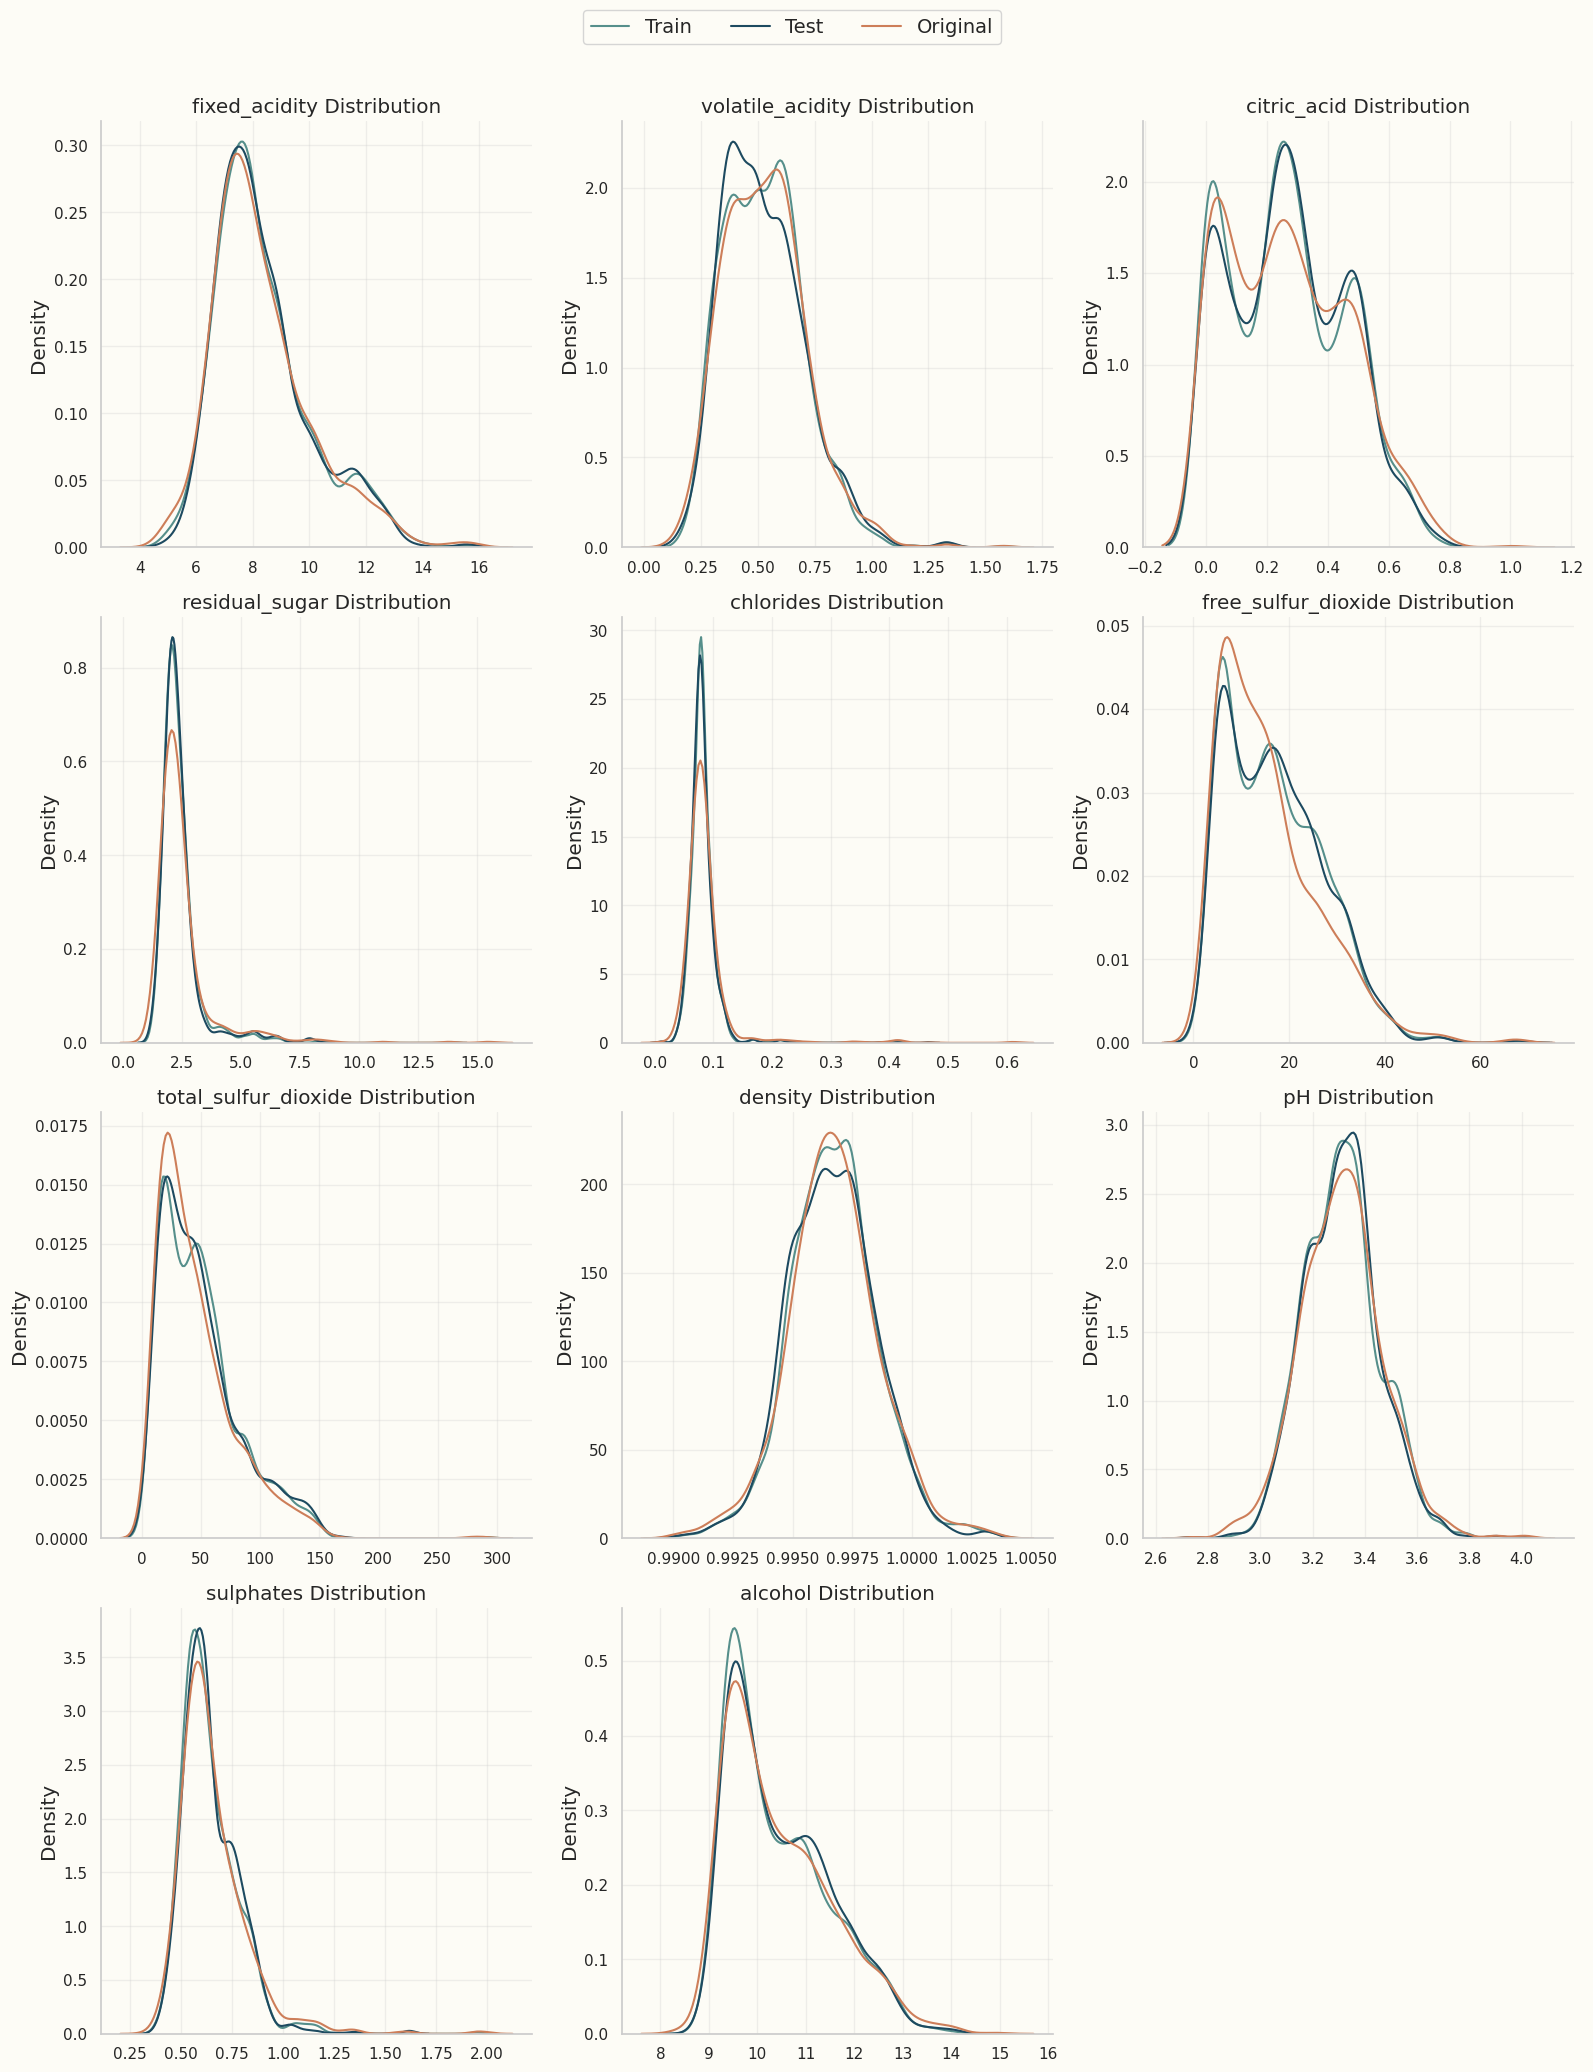

In [7]:
n_bins = 50
histplot_hyperparams = {
    'kde':True,
    'alpha':0.4,
    'stat':'percent',
    'bins':n_bins
}

columns = features
n_cols = 3
n_rows = math.ceil(len(columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
ax = ax.flatten()

for i, column in enumerate(columns):
    plot_axes = [ax[i]]

    sns.kdeplot(
        train_df[column], label='Train',
        ax=ax[i], color=colors[1]
    )

    sns.kdeplot(
        test_df[column], label='Test',
        ax=ax[i], color=colors[2]
    )

    sns.kdeplot(
        original_df[column], label='Original',
        ax=ax[i], color=colors[3]
    )

    # titles
    ax[i].set_title(f'{column} Distribution');
    ax[i].set_xlabel(None)

    # remove axes to show only one at the end
    plot_axes = [ax[i]]
    handles = []
    labels = []
    for plot_ax in plot_axes:
        handles += plot_ax.get_legend_handles_labels()[0]
        labels += plot_ax.get_legend_handles_labels()[1]
        plot_ax.legend().remove()

for i in range(i+1, len(ax)):
    ax[i].axis('off')

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), fontsize=14, ncol=3)
plt.tight_layout()

# Features vs Label Distribution

The features across the dataset show meaningful variation between quality categories, which aligns with the expectation that higher-quality wines are produced under distinct conditions. Notably, chlorides and free sulfur dioxide are anticipated to be particularly influential in predicting quality 3 wines.

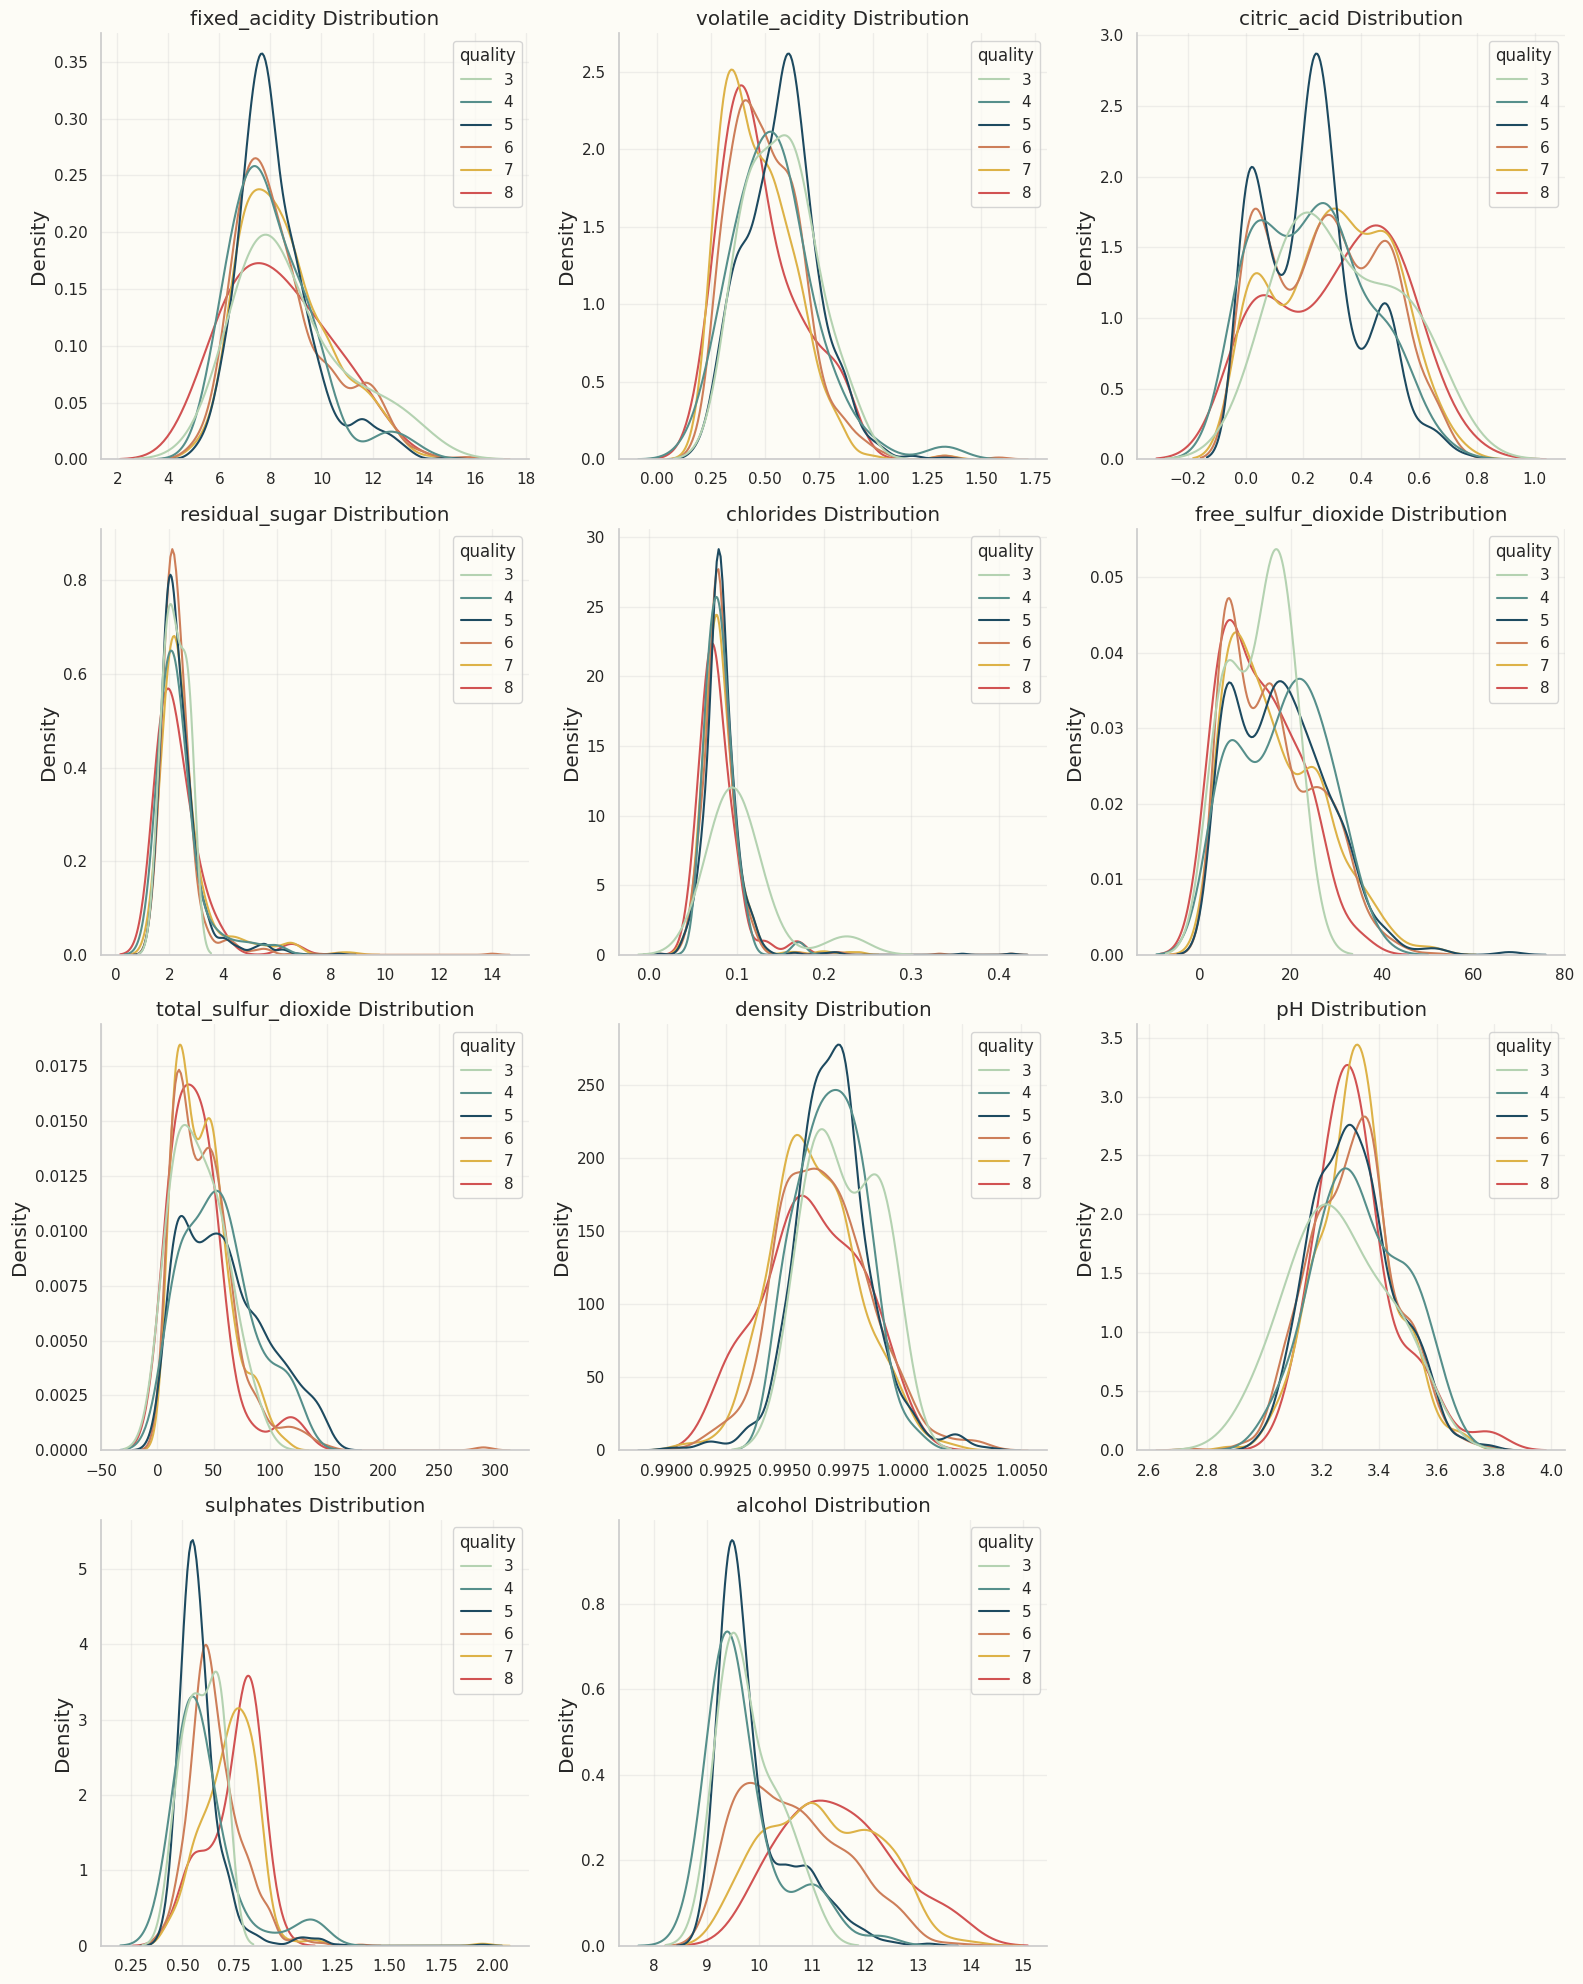

In [8]:
columns = features
n_cols = 3
n_rows = math.ceil(len(columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
ax = ax.flatten()

for i, column in enumerate(columns):
    plot_axes = [ax[i]]

    sns.kdeplot(
        data=train_df,
        x=column,
        hue='quality',
        ax=ax[i],
        common_norm=False,
        palette=palette_rgb
    )

    # titles
    ax[i].set_title(f'{column} Distribution');
    ax[i].set_xlabel(None)

for i in range(i+1, len(ax)):
    ax[i].axis('off')

plt.tight_layout()

# Box Plots

Boxplots provide a concise overview of a dataset's main characteristics, such as outliers, central tendency, distribution shape, and comparisons across groups. They serve as a useful tool in exploratory data analysis, enabling quick recognition of key patterns within the data.


Key Findings:

Two variables—alcohol and sulphates—show a positive linear association with wine quality. In other words, higher levels of alcohol and sulphates tend to correspond with better-quality wines.
Conversely, density and volatile acidity exhibit an inverse relationship with wine quality, meaning that wines with higher density tend to be rated lower in quality.
Wine quality ratings of 5 and 6 contain noticeably more outliers compared to other categories. Because of this, clipping features may not be the best approach—introducing an indicator variable or opting for tree-based models could yield better results.

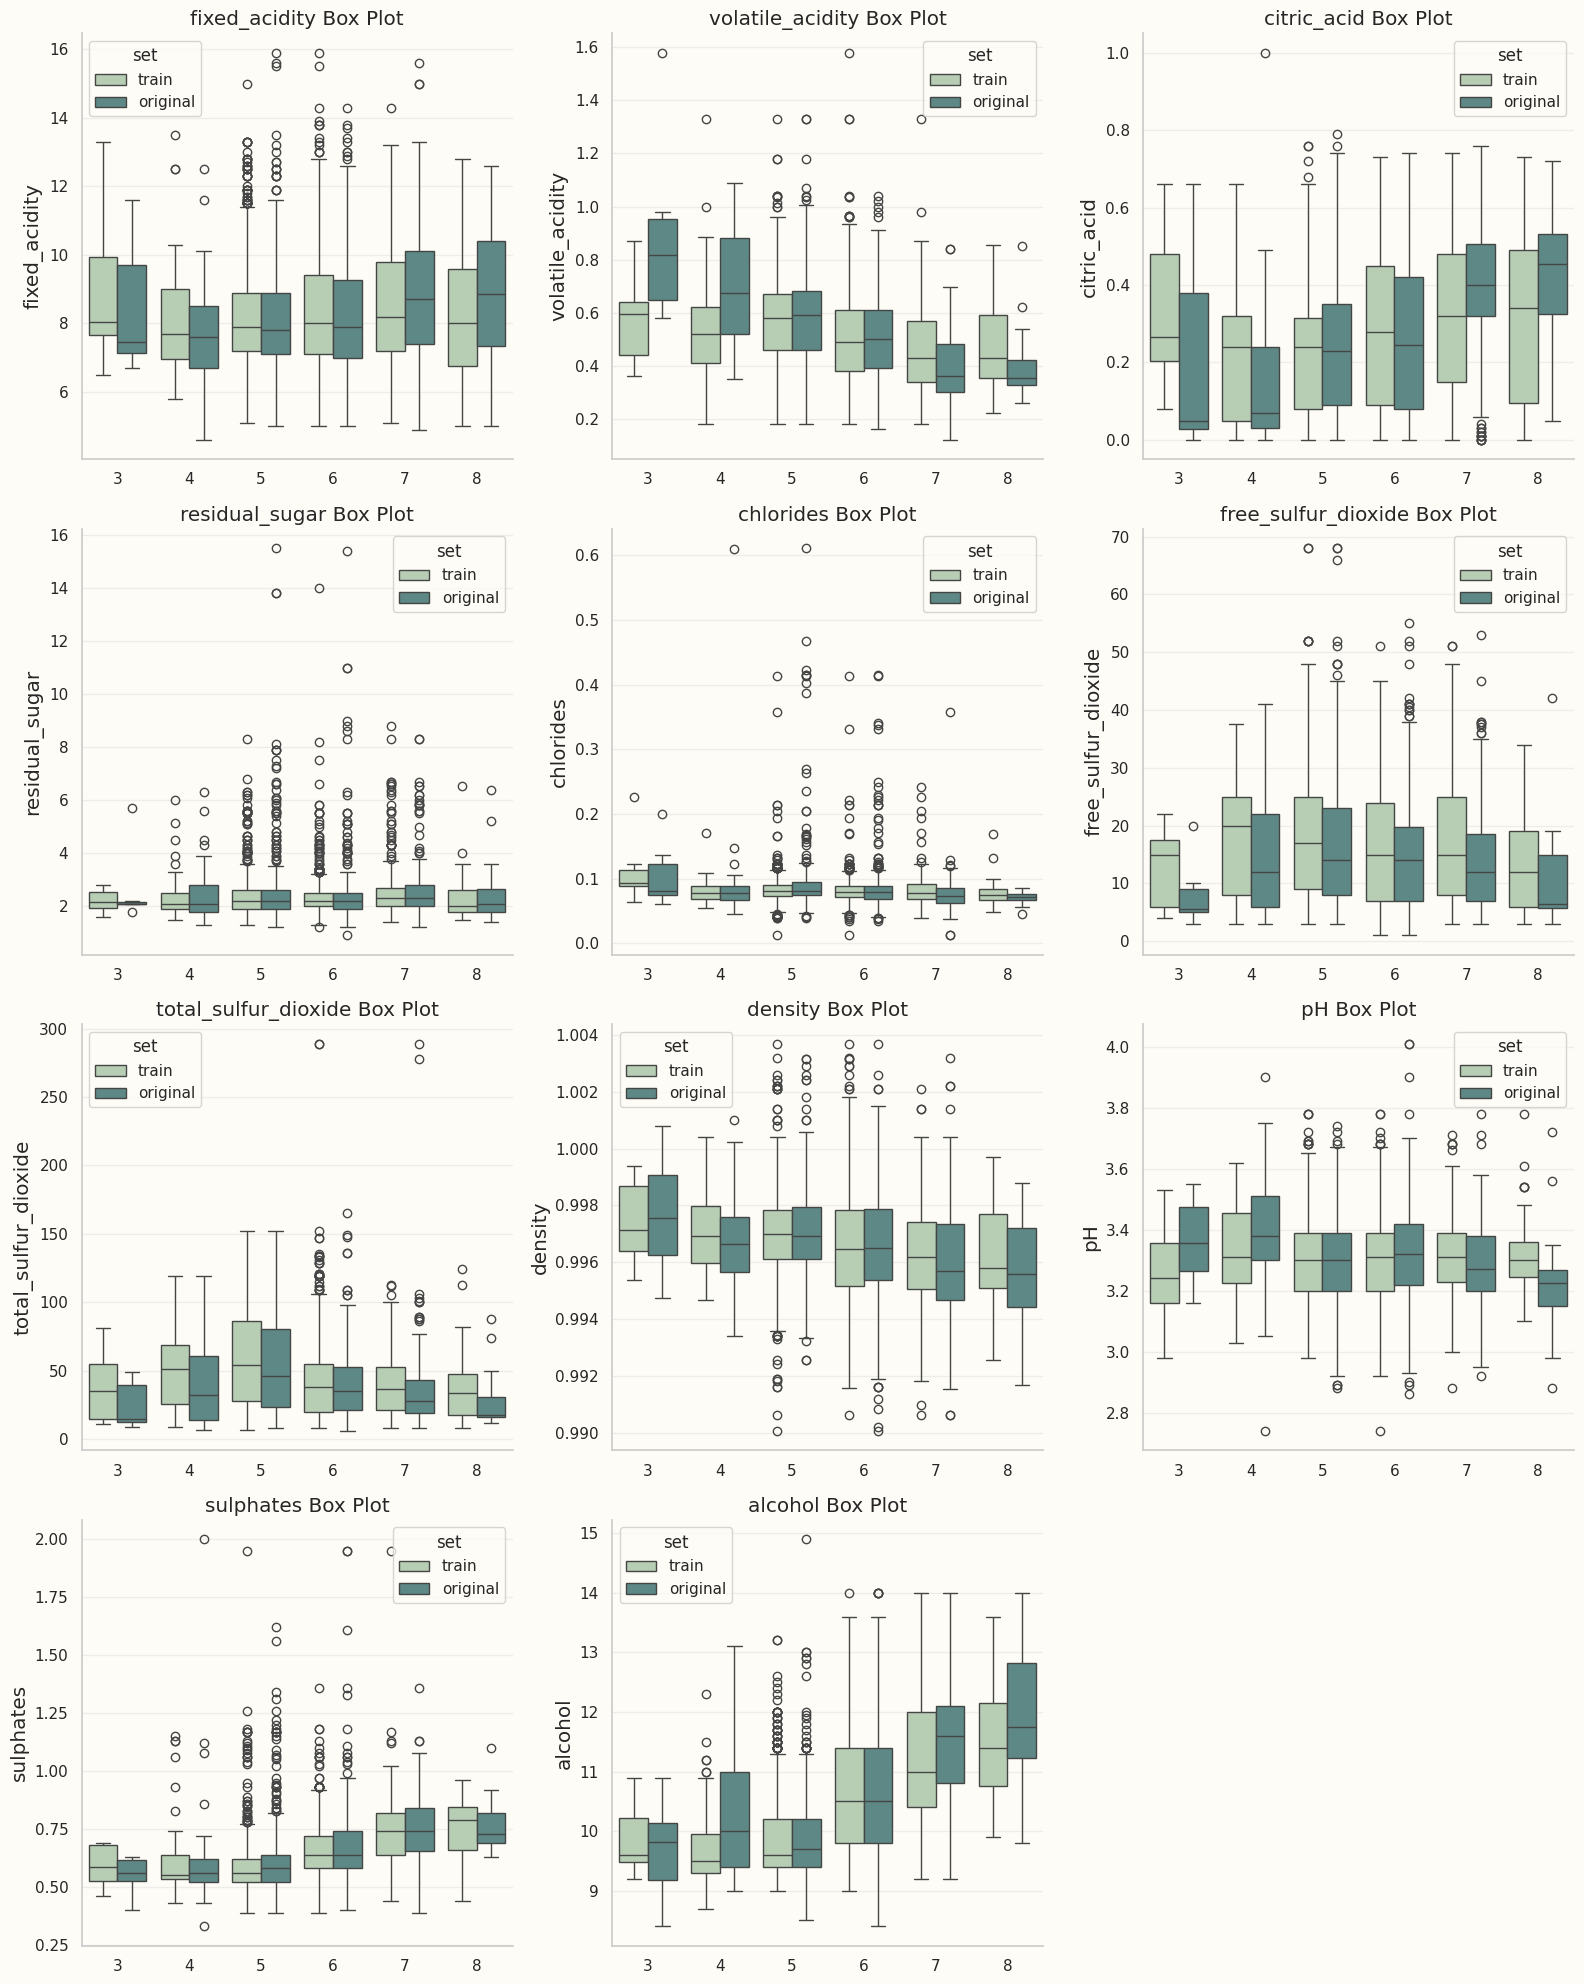

In [11]:
columns = features
n_cols = 3
n_rows = math.ceil(len(columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
ax = ax.flatten()

total_df = pd.concat([train_df, original_df], axis=0)
total_df['set'] = 'original'
total_df.iloc[:train_df.shape[0], -1]  = 'train'
total_df.drop(columns='Id', inplace=True)

for i, column in enumerate(columns):
    plot_axes = [ax[i]]

    sns.boxplot(
        y=total_df[column],
        x=total_df.quality,
        hue=total_df.set,
        ax=ax[i],
    )

    # titles
    ax[i].set_title(f'{column} Box Plot');
    ax[i].set_xlabel(None)

for i in range(i+1, len(ax)):
    ax[i].axis('off')

plt.tight_layout()

#Outliers

The plot displays the count of records within each group whose z-score has an absolute value exceeding 2, flagging them as outliers (i.e., observations lying more than 2 standard deviations away from the mean).

Key Findings:

Preserving outliers is crucial for correctly distinguishing quality values 5, 6, and 7 in features like volatile acidity, citric acid, and density.
For the remaining groups, outliers occur in relatively small numbers. If the joint distributions across classes are sufficiently separable, a simple linear approach such as Linear Discriminant Analysis (LDA) could prove highly effective.

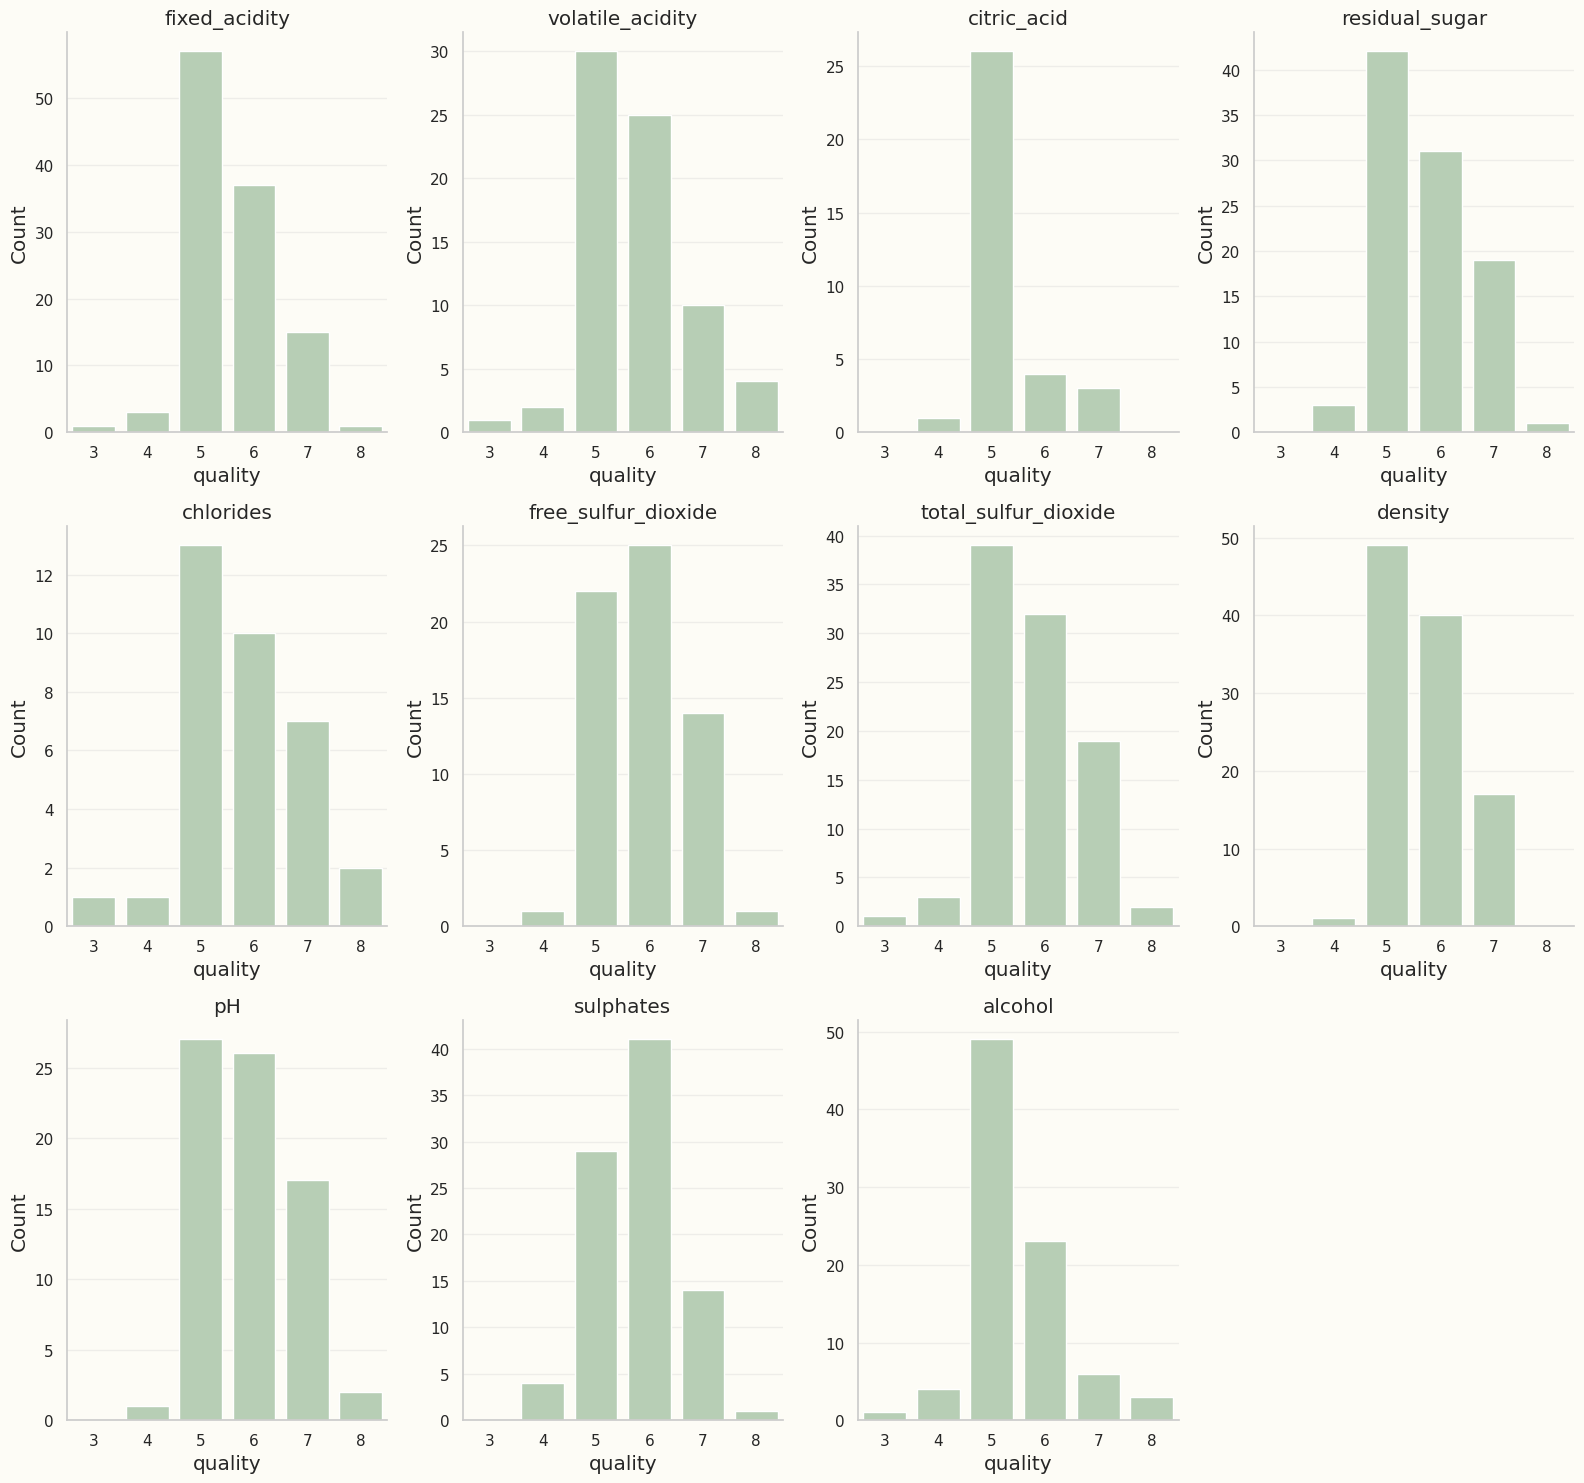

In [13]:
from scipy.stats import zscore

features = train_df.columns[:-1]
z_scores = train_df[features]
z_scores = z_scores.groupby(train_df.quality).transform(zscore)
outliers = z_scores.abs().ge(2).groupby(train_df.quality).sum()

n_cols = 4
n_rows = math.ceil(len(features)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
ax = ax.flatten()

for i, feature in enumerate(features):
    sns.barplot(x=outliers.index, y=outliers[feature], ax=ax[i])
    ax[i].set_ylabel('Count')
    ax[i].set_title(feature)

for i in range(i+1, len(ax)):
    ax[i].axis('off')
plt.tight_layout()

# Missing Values

There are no null values.

In [14]:
train_null = train_df.isnull().sum().rename('train')
test_null = test_df.isnull().sum().rename('test')
original_null = original_df.isnull().sum().rename('original')

pd.concat([train_null, test_null, original_null], axis=1)

,train,test,original
fixed_acidity,0.0,0.0,0
volatile_acidity,0.0,0.0,0
citric_acid,0.0,0.0,0
residual_sugar,0.0,0.0,0
chlorides,0.0,0.0,0
free_sulfur_dioxide,0.0,0.0,0
total_sulfur_dioxide,0.0,0.0,0
density,0.0,0.0,0
pH,0.0,0.0,0
sulphates,0.0,0.0,0


# Correlations

The overall correlation patterns differ between the train and original datasets.
However, the pairwise correlations between individual features and Quality remain consistent across both datasets.

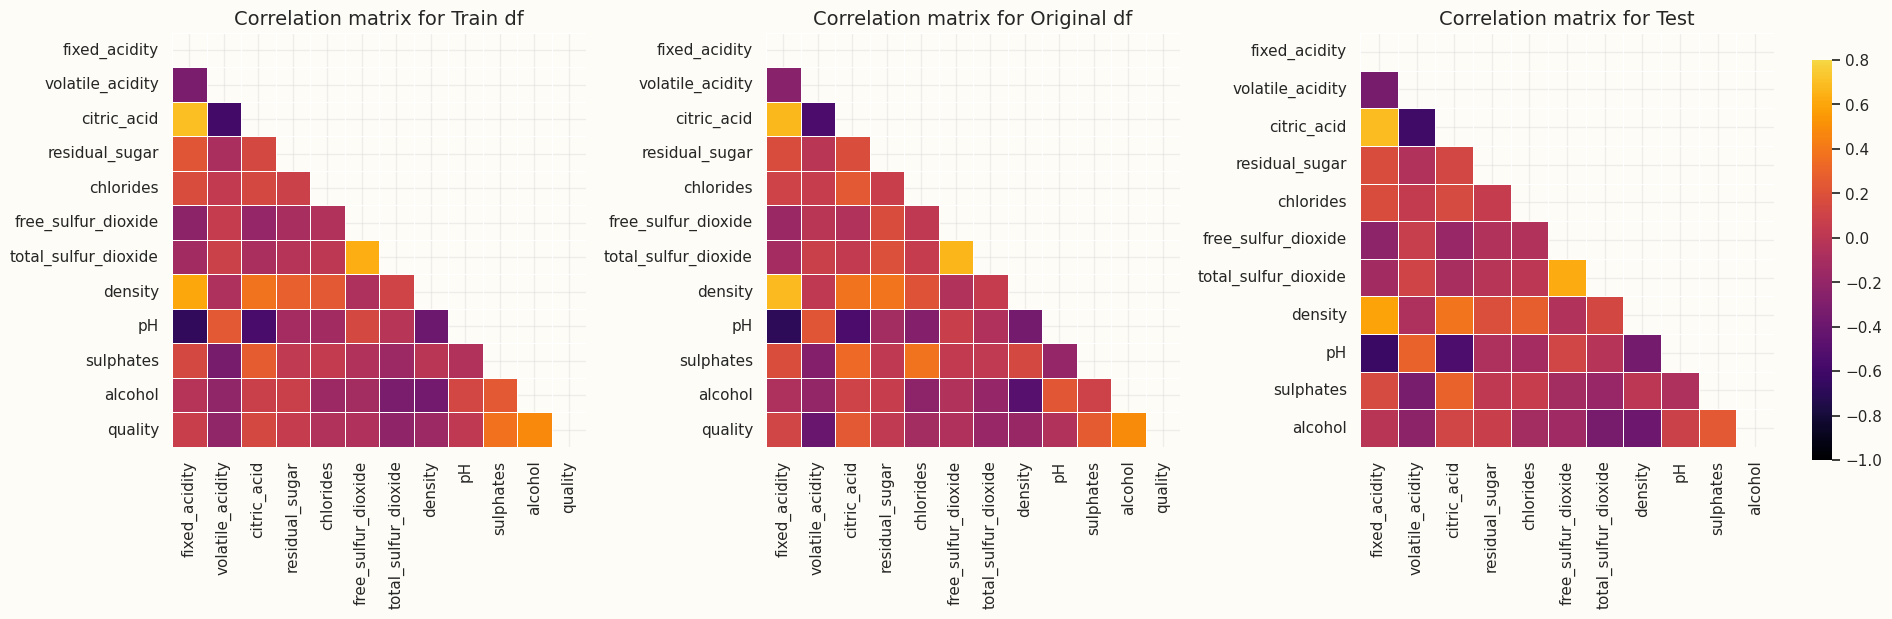

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(20, 20))
float_types = [np.int64, np.float16, np.float32, np.float64]
float_columns = train_df.select_dtypes(include=float_types).columns
cbar_ax = fig.add_axes([.91, .39, .01, .2])

names = ['Train', 'Original']
for i, df in enumerate([train_df, original_df]):

    corr = df[float_columns].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr, mask=mask, cmap='inferno',
        vmax=0.8, vmin=-1,
        center=0, annot=False, fmt='.3f',
        square=True, linewidths=.5,
        ax=ax[i],
        cbar=False,
        cbar_ax=None
    );

    ax[i].set_title(f'Correlation matrix for {names[i]} df', fontsize=14)

df = test_df
float_columns = test_df.select_dtypes(include=float_types).columns
corr = test_df[float_columns].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, cmap='inferno',
    vmax=0.8, vmin=-1,
    center=0, annot=False, fmt='.3f',
    square=True, linewidths=.5,
    cbar_kws={"shrink":.5, 'orientation':'vertical'},
    ax=ax[2],
    cbar=True,
    cbar_ax=cbar_ax
);
ax[2].set_title(f'Correlation matrix for Test', fontsize=14)
fig.tight_layout(rect=[0, 0, .9, 1]);

# Feature Engineering

Building strong features is key to enhancing a model's performance. Effective feature engineering relies on conducting a thorough EDA and gaining a deep understanding of the problem in order to uncover meaningful relationships between the features and the target variable. The insights gathered through this process enable us to design new features that better capture more complex patterns in the data.

Below are a few ideas inspired by the previous plots—the greater the distinction between boxplots, the more beneficial it is for the model.

/tmp/ipykernel_1002/3649000534.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1002/3649000534.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1002/3649000534.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1002/3649000534.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1002/3649000534.py:24: FutureWarning: 

P

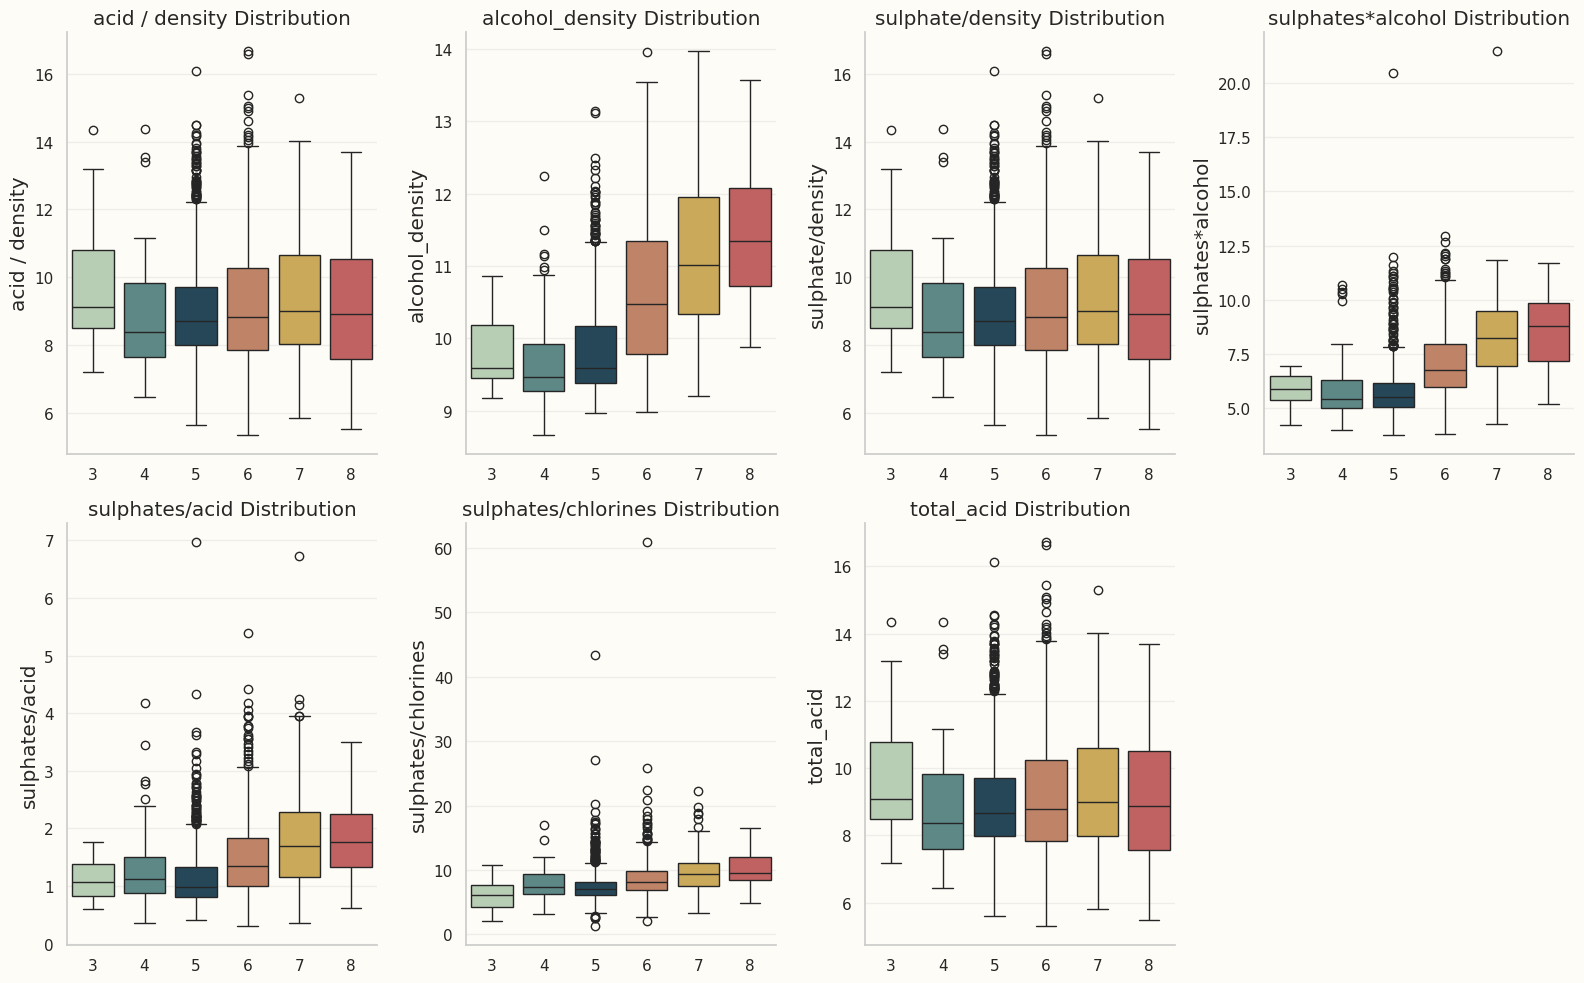

In [16]:
def FE(X):
    X['total_acid'] = X['fixed_acidity'] + X['volatile_acidity'] + X['citric_acid']
    X['acid / density'] = X['total_acid']  / X['density']
    X['alcohol_density'] = X['alcohol']  * X['density']
    X['sulphate/density'] = X['total_acid']  / X['density']
    X['sulphates/acid'] = X['sulphates'] / X['volatile_acidity']
    X['sulphates/chlorines'] = X['sulphates'] / X['chlorides']
    X['sulphates*alcohol'] = X['sulphates'] * X['alcohol']
    return X

X = train_df.copy()
X = FE(X)
new_cols = X.columns.difference(train_df.columns)

columns = new_cols
n_cols = 4
n_rows = math.ceil(len(columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
ax = ax.flatten()

for i, column in enumerate(columns):
    plot_axes = [ax[i]]

    sns.boxplot(
        y=X[column],
        x=X.quality,
        ax=ax[i],
        palette=palette_rgb
    )

    # titles
    ax[i].set_title(f'{column} Distribution');
    ax[i].set_xlabel(None)

for i in range(i+1, len(ax)):
    ax[i].axis('off')

plt.tight_layout()

# The Most Basic Baseline

In the following code, I'll demonstrate how to set up a cross-validation scheme and append the original dataframe to each fold.

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from lightgbm import LGBMClassifier

cv = StratifiedKFold(5, shuffle=True, random_state=42)
X = train_df[features]
y = train_df.quality

kappas = []
test_preds = []
models = []
oof_preds = pd.Series(0, index=train_df.index)
start = time()

for fold, (tr_ix, vl_ix) in enumerate(cv.split(train_df, train_df.quality)):
    start_fold = time()
    X_tr, y_tr = X.loc[tr_ix].copy(), y.loc[tr_ix]
    X_vl, y_vl = X.loc[vl_ix].copy(), y.loc[vl_ix]

    # concat orginal df
    X_tr = pd.concat([X_tr, original_df[features]])
    y_tr = pd.concat([y_tr, original_df.quality])

    X_tr = FE(X_tr)
    X_vl = FE(X_vl)

    model = LGBMClassifier(max_depth=4, random_state=42, class_weight='balanced')
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_vl)
    oof_preds.iloc[vl_ix] = y_pred
    kappas.append(cohen_kappa_score(y_vl, y_pred, weights='quadratic'))
    models.append(model)

    print('_' * 30)
    print(f'Fold: {fold} - {timedelta(seconds=int(time()-start))}')
    print(f'Quadratic Kappa  : ', kappas[-1])
    print(f'Train Time taken :  {timedelta(seconds=int(time()-start_fold))}')
    print()

print(f'Mean Quadratic Kappa:  {Fore.GREEN}{np.mean(kappas)}{Style.RESET_ALL}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001836 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2830
[LightGBM] [Info] Number of data points in the train set: 2787, number of used features: 18
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

#Regression

This problem can alternatively be approached as a regression task, since quality represents an ordered set of classes. Just remember to round your predictions to the nearest integer and clip the values between 3 and 8.

In [18]:
from lightgbm import LGBMRegressor
import scipy as sp
from functools import partial

qwk = partial(cohen_kappa_score, weights='quadratic')
class LGBMRegressorWithRounder(LGBMRegressor):
    '''
    A light wrapper over LGBMRegressor to deal with the usual problems.
    '''
    def _kappa_loss(self, coef, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 3
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 4
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 5
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 6
            elif pred >= coef[3] and pred < coef[4]:
                X_p[i] = 7
            else:
                X_p[i] = 8

        ll = qwk(y, X_p)
        return -ll

    def fit(self, X, y, **params):
        super().fit(X, y, **params)
        X_pred = super().predict(X)
        loss_partial = partial(self._kappa_loss, X=X_pred, y=y)
        # a little bit of wobble
        initial_coef = list(
            np.array([3.5, 4.5, 5.5, 6.5, 7.5])
        )
        self.round_coef_ = sp.optimize.minimize(loss_partial, initial_coef, method='nelder-mead')
        return self

    def set_params(self, **params):
        self.round_coef_ = None

    def predict_discrete(self, X):
        coef = self.coefficients()
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 3
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 4
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 5
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 6
            elif pred >= coef[3] and pred < coef[4]:
                X_p[i] = 7
            else:
                X_p[i] = 8
        return X_p.astype('int')

    def coefficients(self):
        return self.round_coef_['x']

    def predict(self, X):
        X_pred = super().predict(X)
        return self.predict_discrete(X_pred)

# Regressor Baseline

In [19]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
X = train_df[features]
y = train_df.quality

kappas = []
test_preds = []
models = []
oof_preds = pd.Series(0, index=train_df.index)
start = time()

for fold, (tr_ix, vl_ix) in enumerate(cv.split(train_df, train_df.quality)):
    start_fold = time()
    X_tr, y_tr = X.loc[tr_ix], y.loc[tr_ix]
    X_vl, y_vl = X.loc[vl_ix], y.loc[vl_ix]

    # concat orginal df
    X_tr = pd.concat([X_tr, original_df[features]])
    y_tr = pd.concat([y_tr, original_df.quality])

    X_tr = FE(X_tr)
    X_vl = FE(X_vl)

    model = LGBMRegressorWithRounder(max_depth=4, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_vl)
    oof_preds.iloc[vl_ix] = y_pred
    kappas.append(cohen_kappa_score(y_vl, y_pred, weights='quadratic'))
    models.append(model)

    print('_' * 30)
    print(f'Fold: {fold} - {timedelta(seconds=int(time()-start))}')
    print(f'Quadratic Kappa  : ', kappas[-1])
    print(f'Train Time taken :  {timedelta(seconds=int(time()-start_fold))}')
    print()

print(f'Mean Quadratic Kappa:  {Fore.GREEN}{np.mean(kappas)}{Style.RESET_ALL}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2830
[LightGBM] [Info] Number of data points in the train set: 2787, number of used features: 18
[LightGBM] [Info] Start training from score 5.694654
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

# Confusion Matrix

LGBM struggles significantly when distinguishing between class 5 and class 6. One potential solution would be to train a dedicated model to separate these two classes and incorporate it as a second-step stacking layer. Meanwhile, class 3 is consistently misclassified every time.

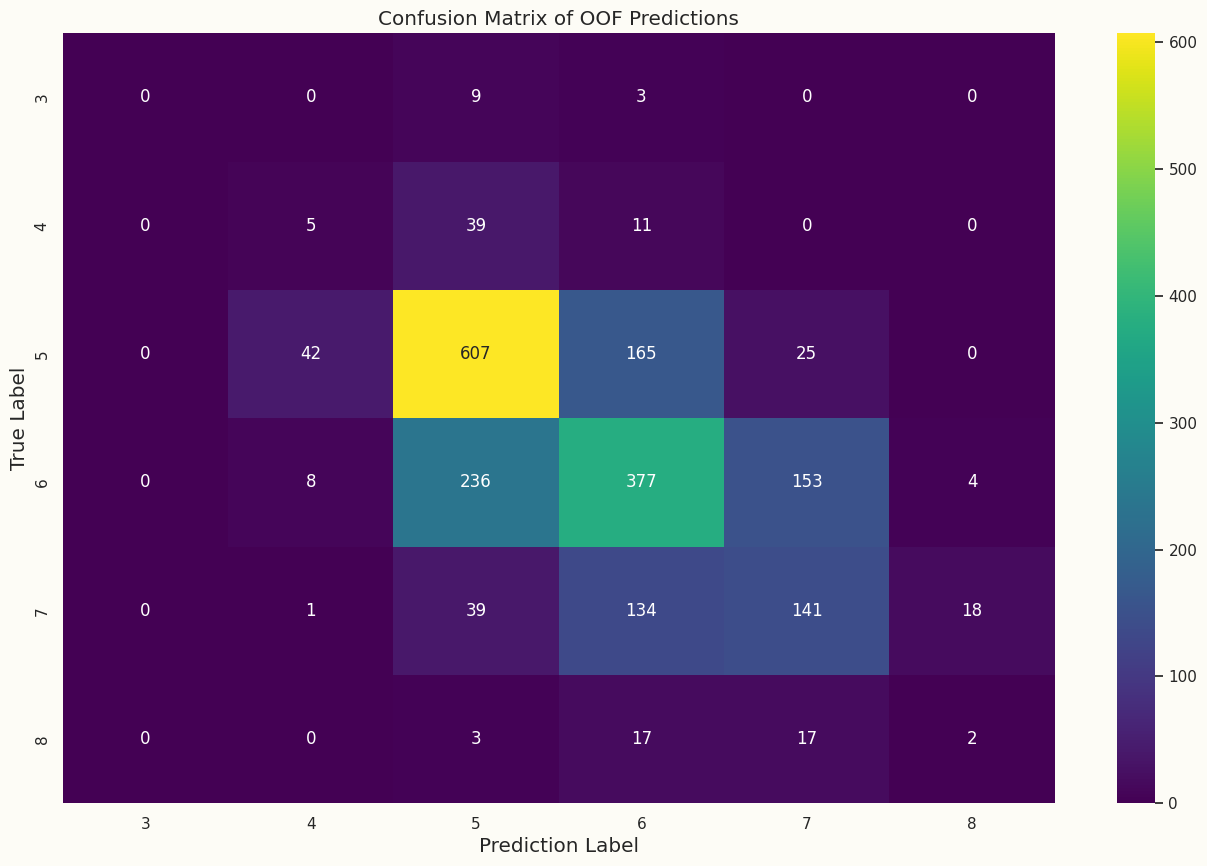

In [20]:
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    confusion_matrix(train_df.quality, oof_preds),
    annot=True,
    cmap='viridis',
    fmt='',
    ax=ax
);

qualities = np.sort(train_df.quality.unique())
ax.set_xticklabels(qualities)
ax.set_yticklabels(qualities)
ax.set_ylabel('True Label')
ax.set_xlabel('Prediction Label')
ax.set_title('Confusion Matrix of OOF Predictions');

In [22]:
# Generate fold prediction
test_preds = {i: model.predict(FE(test_df)) for i, model in enumerate(models)}
test_preds = pd.DataFrame(test_preds)

# Set the correct index
test_preds.set_index(test_df.index, inplace=True)

# Use the mode as ensembling
test_preds = test_preds.mode(axis=1)[0].astype(int)
test_preds.rename('quality', inplace=True)

,quality
Id,
2056,5
2057,6
2058,5
2059,7
2060,6
...,...
3423,5
3424,7
3425,5
